In [2]:
# IMPORTS
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import os
import math

01 - 1.5pt

•Utilizando Matplotlib y Seaborn, crea un gráfico de dispersión (scatter plot) que muestre la relación entre las columnas ‘A’ y ‘B’ del siguiente DataFrame. Además, ajusta una línea de regresión a los datos.

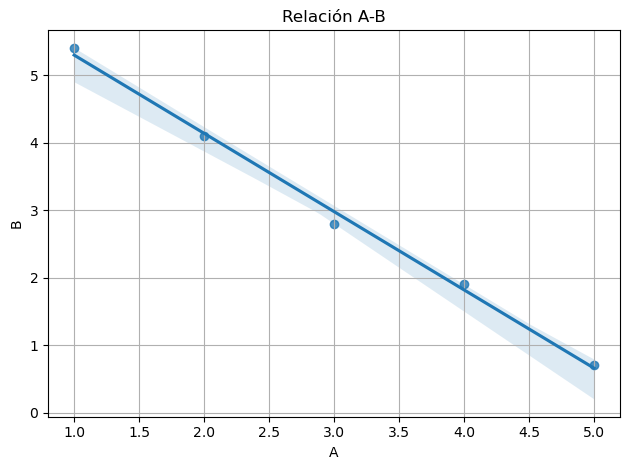

In [3]:
#Data
df = pd.DataFrame({'A': [1, 2, 3, 4, 5], 'B': [5.4, 4.1, 2.8, 1.9, 0.7]})


fig, ax = plt.subplots()
# Paso 1. Crear figura y varios ejes
#ns.swarmplot(x=df["A"], y=df["B"], data=df)

sns.regplot(x=df["A"], y=df["B"], data=df) 

# 2. Dibujar datos en cada eje # O cualquier tipo de

# s= tamaño del punto
# linewidth = tamaño del borde del punto
# edgecolor = color del borde del punto
# 3. Configurar cada eje

ax.set_title("Relación A-B")
ax.set_xlabel("A")
ax.set_ylabel("B")

# Paso 5: ajustes globales
plt.tight_layout() # Evita solapamientos
# Paso 6: elementos auxiliares


ax.grid(True)
# Paso 7: mostrar el gráfico
plt.show()

02 - 1.5pt

•
Escribe una función que reciba un DataFrame, le agregue una nueva columna llamada ‘Promedio’ que sea el promedio de sus columnas Luego, filtre las filas donde el valor de ‘Promedio’ sea mayor que 5 y lo ordene por la columna ‘Promedio’ en orden descendente

In [4]:
def func_mean(df):
    df["Promedio"] = df.mean(axis=1)
    df_filter = df[df["Promedio"]>5].sort_values(by="Promedio", ascending=False)
    df_filter.reset_index(drop=True, inplace=True)
    return df_filter

In [5]:
source_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 7, 6], 'C': [7, 12, 9]})
output = func_mean(source_dataframe) # This calls your function named func_mean

display(output)

,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


In [6]:
# Test Use Case
source_dataframe = pd.DataFrame({'A': [1, 2, 3], 'B': [4, 7, 6], 'C': [7, 12, 9]})
expected_dataframe = pd.DataFrame({'A': [2, 3], 'B': [7, 6], 'C': [12, 9], 'Promedio':[7.0, 6.0]})
output = func_mean(source_dataframe) # This calls your function named func_mean
display(expected_dataframe)
display(output)
assert(expected_dataframe.equals(output)) # This will fail if the dataframe is wrong

,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


,A,B,C,Promedio
0,2,7,12,7.0
1,3,6,9,6.0


03 - 1.5pt

•
Escribe una función que cada vez que se le invoque devuelva el factorial del siguiente número entero, empezando por 1, hasta cualquier número infinito

In [7]:
def fact_gen():
    n=1
    while True:
        factorial=1
        for i in range(1, n+1):
            factorial*=i
        yield factorial
        n+=1

In [8]:
# Test Use Case
expected_output = [1, 2, 6, 24, 120, 720, 5040, 40320]
g = fact_gen() # This calls your function named fact_gen
output = [next(g) for n in range(len(expected_output))]
display(expected_output)
display(output)
assert(expected_output == output) # This will fail if the list is wrong
[1, 2, 6, 24, 120, 720, 5040, 40320]
[1, 2, 6, 24, 120, 720, 5040, 40320]

[1, 2, 6, 24, 120, 720, 5040, 40320]

[1, 2, 6, 24, 120, 720, 5040, 40320]

[1, 2, 6, 24, 120, 720, 5040, 40320]

04 - 1.5pt

•
Crear una función que reciba un array de NumPy y que reemplace todos los números primos por sus raices cuadradas

•
Primo es aquel número natural mayor que 1, que solo es divisible por 1 y por si mismo

In [9]:
def prime_per_sqrt(array):
    array = array.astype(float)   # ← CLAVE
    fila = 0
    columna = 0

    for linea in array:
        for n in linea:
            prime = True

            if n < 2:
                prime = False
            else:
                for i in range(2, int(math.sqrt(n)) + 1):
                    if n % i == 0:
                        prime = False
                        break

            if prime:
                array[fila, columna] =  np.trunc(math.sqrt(n)*100)/100

            columna += 1

        columna = 0
        fila += 1

    return array


In [10]:
source_array = np.array([[20, 17, 33, 11], [3, 25, 5, 49], [18, 28, 32, 2], [9, 1, 23, 40]])
output = prime_per_sqrt(source_array)
display(output)
source_array[0, 0]

array([[20.  ,  4.12, 33.  ,  3.31],
       [ 1.73, 25.  ,  2.23, 49.  ],
       [18.  , 28.  , 32.  ,  1.41],
       [ 9.  ,  1.  ,  4.79, 40.  ]])

np.int64(20)

In [11]:
# Test Use Case
source_array = np.array([[20, 17, 33, 11], [3, 25, 5, 49], [18, 28, 32, 2], [9, 1, 23, 40]])
expected_output = np.array([[20, 4.12, 33, 3.31], [1.73, 25, 2.23, 49], [18, 28, 32, 1.41], [9, 1, 4.79, 40]])
output = prime_per_sqrt(source_array) # This calls your function named prime_per_sqrt
display(expected_output)
display(output)
assert(np.allclose(output, expected_output, atol = 0.01)) # This will fail if the array is wrong
array([[20. , 4.12, 33. , 3.31], [ 1.73, 25. , 2.23, 49. ], [18. , 28. , 32. , 1.41], [ 9. , 1. , 4.79, 40. ]])
array([[20. , 4.12, 33. , 3.32], [ 1.73, 25. , 2.24, 49. ], [18. , 28. , 32. , 1.41], [ 9. , 1. , 4.8 , 40. ]])

array([[20.  ,  4.12, 33.  ,  3.31],
       [ 1.73, 25.  ,  2.23, 49.  ],
       [18.  , 28.  , 32.  ,  1.41],
       [ 9.  ,  1.  ,  4.79, 40.  ]])

array([[20.  ,  4.12, 33.  ,  3.31],
       [ 1.73, 25.  ,  2.23, 49.  ],
       [18.  , 28.  , 32.  ,  1.41],
       [ 9.  ,  1.  ,  4.79, 40.  ]])

NameError: name 'array' is not defined

05 - 4pt
El conjunto de datos "estaciones_bici.csv" (fichero disponible adjunto al notebook) proviene de una descarga de datos del servicio web de la empresa municipal Valenbici, dedicada al alquiler de bicicletas en Valencia.

Los datos recabados de este servicio web son de mediciones cada 10 minutos de las estaciones:
https://valencia.opendatasoft.com/explore/dataset/valenbisi-disponibilitat-valenbisi-dsiponibilidad/information/
Cada estación está compuesta por un número variable de bornetas (total) donde se pueden anclar las bicicletas. Los datos obtenidos de cada estación (registros) refleja el número de bornetas libres (free) y el número de bicicletas disponibles (available).

Columnas para trabajar:

•
station: id de la estación

•
total: número total de bornetas

•
updated: timestamp del estado en de bicis en la estación

•
available: número de bicis disponibles

Preguntas

1.
Carga de datos de csv (estaciones_bici.csv) en un DataFrame, descripción de los datos

3.
¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 25 bornetas, y cuales son


5.
Número de estación con la media más baja de bicis disponibles


7.
Realizar el histograma de bicis disponibles de la estación del punto anterior


9.
Realizar gráfica con la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fecha



In [12]:
#1
ruta = os.path.join("res", "2324excel.csv")
df = pd.read_csv(ruta, sep=";")
df.drop(columns=["Unnamed: 0", "_id", "connected", "download_date", "free", "open", "ticket"], inplace=True)
df

,available,station,total,updated
0,9,64,20,2019-02-10 17:21:13.000
1,6,73,20,2019-02-10 17:24:13.000
2,20,63,20,2019-02-10 18:09:16.000
3,6,64,20,2019-02-10 18:12:15.000
4,9,65,19,2019-02-10 18:09:16.000
...,...,...,...,...
27542,0,260,20,2019-02-11 23:42:16.000
27543,15,261,19,2019-02-11 23:39:16.000
27544,1,268,10,2019-02-11 23:42:16.000
27545,1,269,15,2019-02-11 23:39:16.000


¿Cuál es el rango temporal del dataset? Obtención del número de estaciones que tienen un total de 25 bornetas, y cuales son

In [13]:
df["updated"] = pd.to_datetime(df["updated"], errors="coerce")
print(df["updated"].max())
print(df["updated"].min())
df_25_bornetas=df[df["total"]==25]
x=df_25_bornetas.groupby("station")["total"].count()
print(x)
print(len(x))


2019-02-11 23:42:16
2019-02-10 17:21:13
station
1      100
4      100
9      100
28     100
36     100
49     100
52      99
53      99
55      99
66     100
69     100
75     100
80     100
83      99
106     99
124     99
128     99
142    100
150    100
217    100
Name: total, dtype: int64
20


Número de estación con la media más baja de bicis disponibles

In [14]:
x=df.groupby("station")["total"].mean()
x=x.sort_values(ascending=True)
indice_min=x.idxmin()
indice_min

np.int64(268)

Realizar el histograma de bicis disponibles de la estación del punto anterior



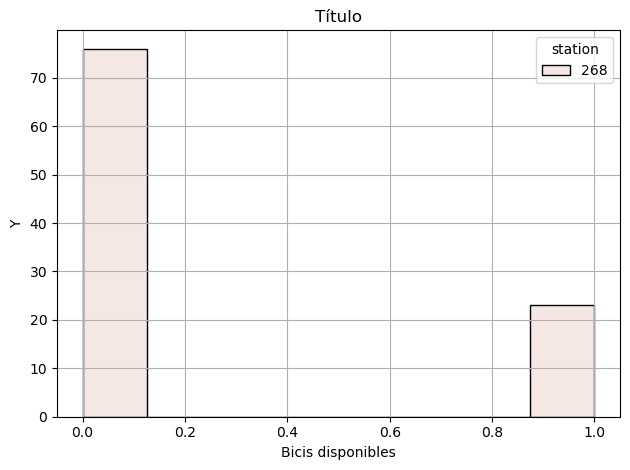

In [26]:
# Paso 1. Crear figura y varios ejes
fig, axs = plt.subplots()

# 2. Dibujar datos en cada eje
df_min=df[df["station"]==indice_min]

sns.histplot(data=df_min, x="available", hue="station") 

# s= tamaño del punto
# linewidth = tamaño del borde del punto
# edgecolor = color del borde del punto

# 3. Configurar cada eje
axs.set_title("Título")
axs.set_xlabel("Bicis disponibles")
axs.set_ylabel("Y")

# Paso 5: ajustes globales
plt.tight_layout() # Evita solapamientos

# Paso 6: elementos auxiliares
axs.grid(True)

# Paso 7: mostrar el gráfico
plt.show()


Realizar gráfica con la línea temporal de bicis disponibles de la estación del punto anterior. Pista, es necesario cambiar el índice a uno tipo fech

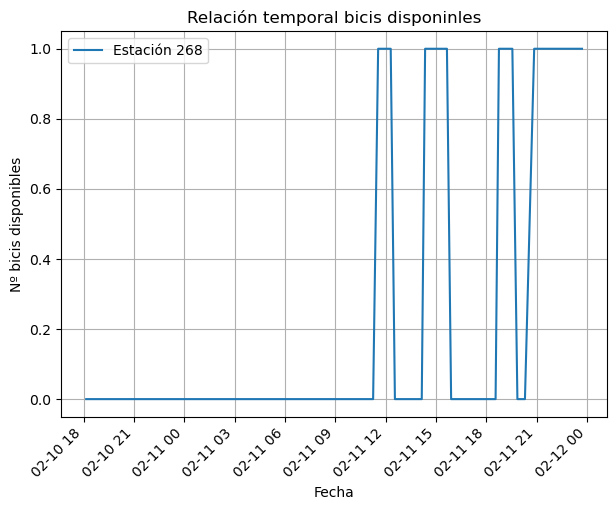

In [22]:
# Paso 1. Crear figura y varios ejes
fig, axs = plt.subplots()
# 2. Dibujar datos en cada eje
x=df_min["updated"]
y=df_min["available"]
axs.plot(x, y, label=f'Estación {indice_min}') # O cualquier tipo de

# s= tamaño del punto
# linewidth = tamaño del borde del punto
# edgecolor = color del borde del punto
# 3. Configurar cada eje
axs.set_title("Relación temporal bicis disponinles")
axs.set_xlabel("Fecha")
axs.set_ylabel("Nº bicis disponibles")

# Paso 5: ajustes globales
plt.tight_layout() # Evita solapamientos
plt.xticks(rotation=45, ha="right")
# Paso 6: elementos auxiliares
axs.grid(True)
axs.legend()
# Paso 7: mostrar el gráfico
plt.show()
